In [1]:
import config
import torch
import sys
sys.path.append('../util')
sys.path.append('../others_networks')
from Trainer import Trainer, evaluate_model
from util import show_dataset_prev
from GenericDatasetReader import get_datasets

#Clone the repository: #https://github.com/LeeJunHyun/Image_Segmentation/blob/master/network.py
#Add the clone location to be able to import from UNets
#The training of these networks was done in colab, so it will be necessary to adapt this script for execution
sys.path.append("/media/calculon/TUDAO/Image_Segmentation")
from network import U_Net
from network import AttU_Net
from network import R2AttU_Net

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
result_path = './colab_unets/'

In [2]:
num_classes  = config.num_classes
in_channels  = config.in_channels
out_channels = 3

train_loader, test_loader, val_loader = get_datasets(dataset_dir=config.dataset_path, 
                                              resolution=config.dataset_resolution, 
                                              batch_size=config.batch_size,
                                              num_classes=num_classes)

torch.Size([16, 3, 256, 256]) torch.Size([16, 1, 256, 256])
4814 198 198


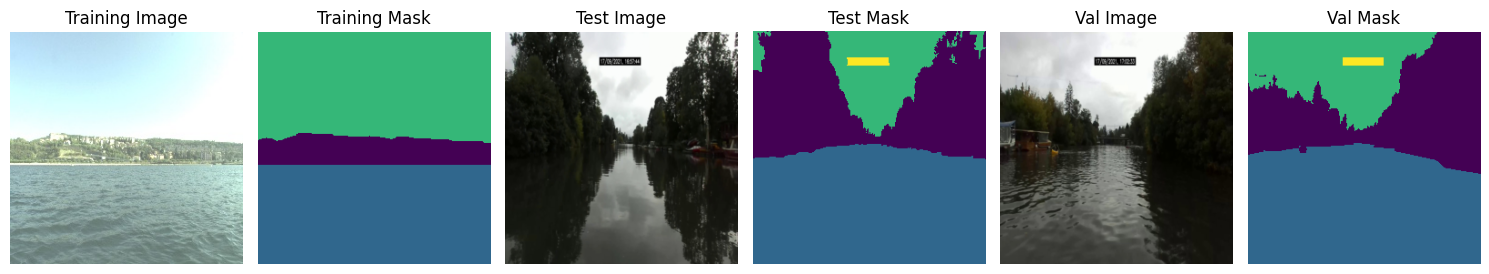

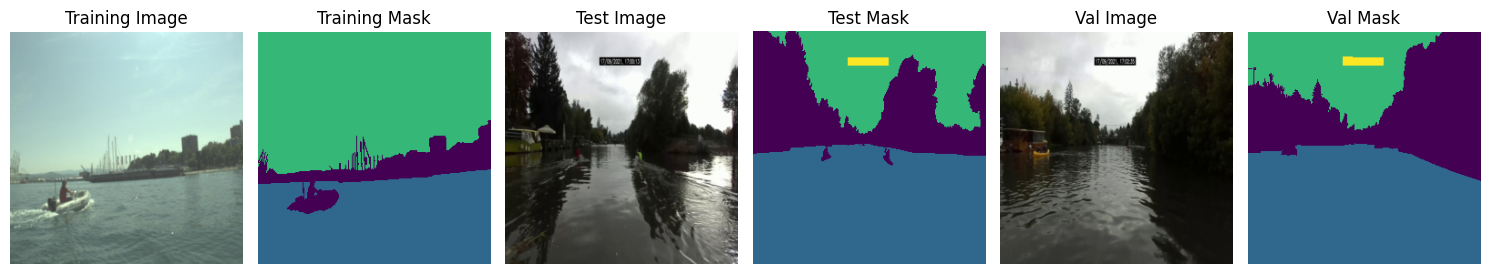

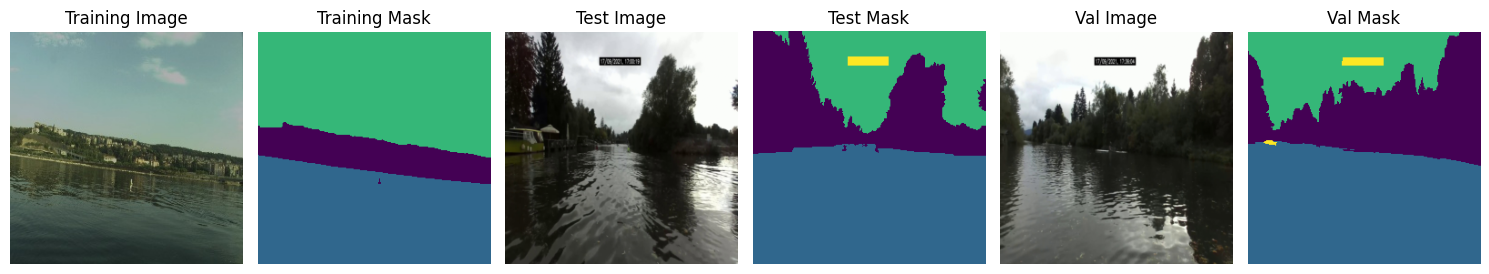

In [3]:
for (images_train, masks_train), (images_test, masks_test) in zip(train_loader, test_loader):
    print(images_train.shape, masks_train.shape)
    break

print(len(train_loader.dataset), len(test_loader.dataset), len(val_loader.dataset))

show_dataset_prev(train_loader, test_loader, val_loader, num_images=3, num_classes=num_classes)

In [4]:
def train(model, model_name=None, epochs=300, re_evaluate=True):
    model_filename = f'{model_name}-epochs{epochs}.pth'

    
    trainer = Trainer(num_classes=num_classes,
                    model_filename=model_filename, 
                    model_dir=result_path, 
                    save_xlsx=True,
                    ignore_index=255)
    model = trainer.train(model, train_loader, val_loader, test_loader,
                            num_epochs=epochs, 
                            verbose=1, 
                            save_every=5, 
                            learning_rate=1e-3,
                            continue_from_last=True,
                            # we are re-evaluating after loading the model 
                            # because we refactored the code and want to see the new results
                            re_evaluate=re_evaluate)
    model.to(device)
    return trainer.get_best_test_stats()



In [9]:
# Here we will load the model weights that were trained in colab
def load_and_evaluate_model(model, test_loader, model_name=None):
    model_filename = f'{result_path}/{model_name}-best.pth'
    state_dict = torch.load(model_filename, map_location='cpu')
    model.load_state_dict(state_dict['model_state_dict'], strict=False)
    model.to('cuda')
    stats_best = evaluate_model(model, test_loader, print_stats=True, ignore_index=255, num_classes=num_classes)

    model_filename = f'{result_path}/{model_name}-last.pth'
    state_dict = torch.load(model_filename, map_location='cpu')
    model.load_state_dict(state_dict['model_state_dict'], strict=False)
    model.to('cuda')
    stats_last = evaluate_model(model, test_loader, print_stats=True, ignore_index=255, num_classes=num_classes)

    if stats_best['f1'] > stats_last['f1']:
        return stats_best
    else:
        return stats_last

In [10]:
model = U_Net(img_ch=in_channels, output_ch=out_channels)
#stats1 = train(model,'UNet-1')
stats1 = load_and_evaluate_model(model, test_loader, 'UNet-1')

Loss: 0.0000 F1: 0.9843 mIoU: 0.9694 Prec: 0.9841 Recall: 0.9845 Q: 0.9542
Loss: 0.0000 F1: 0.9845 mIoU: 0.9698 Prec: 0.9852 Recall: 0.9837 Q: 0.9547


In [11]:
model = U_Net(img_ch=in_channels, output_ch=out_channels)
#stats2 = train(model,'UNet-2')
stats2 = load_and_evaluate_model(model, test_loader, 'UNet-2')

Loss: 0.0000 F1: 0.9836 mIoU: 0.9682 Prec: 0.9838 Recall: 0.9835 Q: 0.9524
Loss: 0.0000 F1: 0.9836 mIoU: 0.9682 Prec: 0.9838 Recall: 0.9835 Q: 0.9524


In [12]:
model = U_Net(img_ch=in_channels, output_ch=out_channels)
#stats3 = train(model,'UNet-3')
stats3 = load_and_evaluate_model(model, test_loader, 'UNet-3')

Loss: 0.0000 F1: 0.9835 mIoU: 0.9680 Prec: 0.9835 Recall: 0.9835 Q: 0.9520
Loss: 0.0000 F1: 0.9841 mIoU: 0.9690 Prec: 0.9845 Recall: 0.9837 Q: 0.9536


In [13]:
print("U-Net")
print("AVG F1-Score:", round((stats1['f1']+stats2['f1']+stats3['f1'])/3.0,3) )
print("Max F1-Score:", round(max(stats1['f1'],stats2['f1'],stats3['f1']),3) )

print("AVG mIoU:", round((stats1['miou']+stats2['miou']+stats3['miou'])/3.0,3) )
print("AVG mIoU:", round(max(stats1['miou'],stats2['miou'],stats3['miou']),3) )

U-Net
AVG F1-Score: 0.984
Max F1-Score: 0.984
AVG mIoU: 0.969
AVG mIoU: 0.97


In [14]:
model = AttU_Net(img_ch=in_channels, output_ch=out_channels)
#stats1 = train(model,'AttU_Net-1')
stats1 = load_and_evaluate_model(model, test_loader, 'AttU_Net-1')

Loss: 0.0000 F1: 0.9819 mIoU: 0.9649 Prec: 0.9817 Recall: 0.9820 Q: 0.9474
Loss: 0.0000 F1: 0.9831 mIoU: 0.9672 Prec: 0.9837 Recall: 0.9825 Q: 0.9508


In [15]:
model = AttU_Net(img_ch=in_channels, output_ch=out_channels)
#stats2 = train(model,'AttU_Net-2')
stats2 = load_and_evaluate_model(model, test_loader, 'AttU_Net-2')

Loss: 0.0000 F1: 0.9834 mIoU: 0.9677 Prec: 0.9829 Recall: 0.9839 Q: 0.9516
Loss: 0.0000 F1: 0.9847 mIoU: 0.9702 Prec: 0.9843 Recall: 0.9851 Q: 0.9553


In [16]:
model = AttU_Net(img_ch=in_channels, output_ch=out_channels)
#stats3 = train(model,'AttU_Net-3')
stats3 = load_and_evaluate_model(model, test_loader, 'AttU_Net-3')

Loss: 0.0000 F1: 0.9845 mIoU: 0.9699 Prec: 0.9838 Recall: 0.9853 Q: 0.9549
Loss: 0.0000 F1: 0.9849 mIoU: 0.9706 Prec: 0.9846 Recall: 0.9852 Q: 0.9560


In [17]:
print("Attention U-Net")
print("AVG F1-Score:", round((stats1['f1']+stats2['f1']+stats3['f1'])/3.0,3) )
print("Max F1-Score:", round(max(stats1['f1'],stats2['f1'],stats3['f1']),3) )

print("AVG mIoU:", round((stats1['miou']+stats2['miou']+stats3['miou'])/3.0,3) )
print("AVG mIoU:", round(max(stats1['miou'],stats2['miou'],stats3['miou']),3) )

Attention U-Net
AVG F1-Score: 0.984
Max F1-Score: 0.985
AVG mIoU: 0.969
AVG mIoU: 0.971


In [18]:
model = R2AttU_Net(img_ch=in_channels, output_ch=out_channels)
#stats1 = train(model,'R2AttU_Net-1')
stats1 = load_and_evaluate_model(model, test_loader, 'R2AttU_Net-1')

Loss: 0.0000 F1: 0.9775 mIoU: 0.9568 Prec: 0.9773 Recall: 0.9779 Q: 0.9354
Loss: 0.0000 F1: 0.9791 mIoU: 0.9597 Prec: 0.9801 Recall: 0.9782 Q: 0.9397


In [19]:
model = R2AttU_Net(img_ch=in_channels, output_ch=out_channels)
#stats2 = train(model,'R2AttU_Net-2')
stats2 = load_and_evaluate_model(model, test_loader, 'R2AttU_Net-2')

Loss: 0.0000 F1: 0.9804 mIoU: 0.9622 Prec: 0.9793 Recall: 0.9817 Q: 0.9434
Loss: 0.0000 F1: 0.9803 mIoU: 0.9620 Prec: 0.9774 Recall: 0.9835 Q: 0.9431


In [20]:
model = R2AttU_Net(img_ch=in_channels, output_ch=out_channels)
#stats3 = train(model,'R2AttU_Net-3')
stats3 = load_and_evaluate_model(model, test_loader, 'R2AttU_Net-3')

Loss: 0.0000 F1: 0.9799 mIoU: 0.9613 Prec: 0.9775 Recall: 0.9826 Q: 0.9421
Loss: 0.0000 F1: 0.9790 mIoU: 0.9596 Prec: 0.9782 Recall: 0.9800 Q: 0.9396


In [21]:
print("Recurrent Attention U-Net")
print("AVG F1-Score:", round((stats1['f1']+stats2['f1']+stats3['f1'])/3.0,3) )
print("Max F1-Score:", round(max(stats1['f1'],stats2['f1'],stats3['f1']),3) )

print("AVG mIoU:", round((stats1['miou']+stats2['miou']+stats3['miou'])/3.0,3) )
print("AVG mIoU:", round(max(stats1['miou'],stats2['miou'],stats3['miou']),3) )

Recurrent Attention U-Net
AVG F1-Score: 0.98
Max F1-Score: 0.98
AVG mIoU: 0.961
AVG mIoU: 0.962
